# SSA MEC Scatter Plot Analysis

Load **monthly gridded** AeroCom pickles, define regions with `create_region_mask()`,
aggregate with `regional_aggregate()`, and compute MEC / MAC / SSA in the notebook.

Regions: **global**, **africa**, **amazon**, **outflow_af** (same boxes and fire seasons as before).

Two plot sets:
1. **Regional mean** scatter plots (one point per model)
2. **Monthly** scatter / time-series plots (one point per model per month)


## 1. Setup System Path and Import Modules

In [1]:
import sys
import os

# Add parent directory to system path to allow imports
notebook_dir = os.path.dirname(os.path.abspath('SSA_MEC_scatter_plot.ipynb'))
project_root = os.path.dirname(notebook_dir)
py_dir = os.path.join(project_root, 'py')

# Add paths to sys.path if not already present
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if py_dir not in sys.path:
    sys.path.insert(0, py_dir)

print(f"Project root: {project_root}")
print(f"Python directory: {py_dir}")
print(f"System path updated: {sys.path[:3]}")

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python directory: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py
System path updated: ['/net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py', '/net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom', '']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from pathlib import Path

# Import project modules
try:
    from py import functions
    from py import aerocom_data
    print('Successfully imported functions and aerocom_data')
except ImportError:
    import functions
    import aerocom_data
    print('Successfully imported functions and aerocom_data (from py dir)')
    


Successfully imported functions and aerocom_data


## 2. Define Data Paths

Monthly gridded pickles are produced by `py/get_data.py` in `Data/var_files/original/monthly/`.


In [3]:
monthly_dir = Path(project_root) / 'Data' / 'var_files' / 'original' / 'monthly'
average_dir = Path(project_root) / 'Data' / 'var_files' / 'original' / 'average'

print(f'Monthly pickle directory: {monthly_dir}')
print(f'  exists: {monthly_dir.exists()}')
print(f'Legacy average directory: {average_dir}')
print(f'  exists: {average_dir.exists()}')

if monthly_dir.exists():
    monthly_files = sorted(monthly_dir.glob('*.pickle'))
    print(f'\nMonthly pickle files ({len(monthly_files)}):')
    for f in monthly_files:
        print(f'  - {f.name}')
else:
    print('\nMonthly directory missing — run py/get_data.py first.')


Monthly pickle directory: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/var_files/original/monthly
  exists: True
Legacy average directory: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/var_files/original/average
  exists: True

Monthly pickle files (11):
  - abs550.pickle
  - emi_BC.pickle
  - emi_BC_OA.pickle
  - emi_OA.pickle
  - emi_total.pickle
  - load_BC.pickle
  - load_BC_OA.pickle
  - load_OA.pickle
  - load_total.pickle
  - od550.pickle
  - od_other.pickle


## 3. Load monthly gridded pickles

Base variables are aggregated in the next section; MEC, MAC, and SSA are derived here.


In [4]:
def load_pickle_file(file_path):
    """Load a pickle file and return the data."""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except FileNotFoundError:
        print(f'File not found: {file_path}')
        return None
    except Exception as e:
        print(f'Error loading {file_path}: {e}')
        return None


def load_monthly(name):
    path = monthly_dir / name
    print(f'Loading {name} ... ', end='')
    data = load_pickle_file(path)
    print('ok' if data else 'missing')
    return data


od550      = load_monthly('od550.pickle')
abs550     = load_monthly('abs550.pickle')
load_total = load_monthly('load_total.pickle')
load_BC_OA = load_monthly('load_BC_OA.pickle')

emi_total = load_monthly('emi_total.pickle')
emi_BC_OA = load_monthly('emi_BC_OA.pickle')

required = {'od550': od550, 'abs550': abs550, 'load_total': load_total, 'load_BC_OA': load_BC_OA}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise FileNotFoundError(f'Missing monthly pickles: {missing}. Run py/get_data.py first.')

print(f"\nModels in od550: {len(od550)} | abs550: {len(abs550)} | load: {len(load_total)}")


Loading od550.pickle ... ok
Loading abs550.pickle ... ok
Loading load_total.pickle ... ok
Loading load_BC_OA.pickle ... ok
Loading emi_total.pickle ... ok
Loading emi_BC_OA.pickle ... ok

Models in od550: 17 | abs550: 17 | load: 17


In [5]:
od550

{'CAM5-ATRAS_AP3-CTRL': {'emi': {'emibc': ['Column', 1, 'monthly'],
   'emidust': ['Column', 1, 'monthly'],
   'emiss': ['Column', 1, 'monthly'],
   'emioa': ['Column', 1, 'monthly'],
   'emiso2': ['Column', 1, 'monthly']},
  'emi_bc': 0,
  'emi_dust': 0,
  'emi_ss': 0,
  'emi_oa': 0,
  'emi_so2': 0,
  'emi_total': 0,
  'emi_BC_OA': 0,
  'load': {'loadbc': ['Column', 1, 'monthly'],
   'loaddu': ['Column', 1, 'monthly'],
   'loadss': ['Column', 1, 'monthly'],
   'loadoa': ['Column', 1, 'monthly'],
   'loadso4': ['Column', 1, 'monthly']},
  'load_bc': 0,
  'load_dust': 0,
  'load_ss': 0,
  'load_oa': 0,
  'load_so4': 0,
  'load_total': 0,
  'load_BC_OA': 0,
  'od550aer': {'od550aer': ['Column', 'monthly']},
  'od440aer': {'od440aer': ['Column', 'monthly']},
  'abs550aer': {'abs550aer': ['Column', 'monthly']},
  'AOD550': <xarray.DataArray 'od550aer' (time: 12, lat: 96, lon: 144)> Size: 664kB
  [165888 values with dtype=float32]
  Coordinates:
    * time     (time) datetime64[ns] 96B 2010

## 4. Examine loaded data structure


In [9]:
sample_model = next(iter(od550.keys()))
sample_da = od550[sample_model]['AOD550']
print(f'Sample model: {sample_model}')
print(f'AOD550 dims: {sample_da.dims}, shape: {sample_da.shape}')
print(f'Time range: {str(sample_da.time.values[0])[:10]} to {str(sample_da.time.values[-1])[:10]}')
print(f'Lat: {float(sample_da.lat.min()):.1f} to {float(sample_da.lat.max()):.1f}')
print(f'Lon: {float(sample_da.lon.min()):.1f} to {float(sample_da.lon.max()):.1f}')


Sample model: CAM5-ATRAS_AP3-CTRL
AOD550 dims: ('time', 'lat', 'lon'), shape: (12, 96, 144)
Time range: 2010-01-01 to 2010-12-01
Lat: -90.0 to 90.0
Lon: 0.0 to 357.5


## 5. Regional masks, aggregation, and derived variables

Uses `functions.create_region_mask()` and `functions.regional_aggregate()` with the
same regions and fire-season windows as the old `apply_global_mean()` workflow.


In [10]:
REGIONS = {
    'global': {
        'lon_range': (0, 360), 'lat_range': (-90, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'africa': {
        'lon_range': (15, 37), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': False,
    },
    'amazon': {
        'lon_range': (287, 317), 'lat_range': (-17, -3),
        'time_slice': ('2010-07-01', '2010-10-31'), 'edge_weighted': False,
    },
    'outflow_af': {
        'lon_range': (350, 8), 'lat_range': (-15, 3),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': True,
    },
}

template = od550[sample_model]['AOD550'].isel(time=0)
masks = {}
for name, cfg in REGIONS.items():
    masks[name] = functions.create_region_mask(
        template,
        name=name,
        lon_range=cfg['lon_range'],
        lat_range=cfg['lat_range'],
        surface=cfg.get('surface', 'all'),
        mask_registry=masks,
        land_mask=1
    )


def aggregate_region(model_dict, var_name, region_name, return_time_series=False):
    cfg = REGIONS[region_name]
    return functions.aggregate_models(
        model_dict,
        var_name,
        masks[region_name],
        spatial='mean',
        edge_weighted=cfg['edge_weighted'],
        time_slice=cfg['time_slice'],
        temporal='mean',
        return_time_series=return_time_series,
    )


def build_derived_dicts(regions):
    """Return MEC, MAC, SSA, lifetime dicts: {region: {model: scalar}}."""
    od_mean = {r: aggregate_region(od550, 'AOD550', r) for r in regions}
    abs_mean = {r: aggregate_region(abs550, 'AAOD550', r) for r in regions}
    load_mean = {r: aggregate_region(load_total, 'load_total', r) for r in regions}
    load_bcoa_mean = {r: aggregate_region(load_BC_OA, 'load_BC_OA', r) for r in regions}

    emi_mean = (
        {r: aggregate_region(emi_total, 'emi_total', r) for r in regions}
        if emi_total is not None else {}
    )
    emi_bcoa_mean = (
        {r: aggregate_region(emi_BC_OA, 'emi_BC_OA', r) for r in regions}
        if emi_BC_OA is not None else {}
    )

    mec, mac, ssa, lifetime, lifetime_bcoa = {}, {}, {}, {}, {}
    for region in regions:
        mec[region], mac[region], ssa[region] = {}, {}, {}
        lifetime[region], lifetime_bcoa[region] = {}, {}
        for model in set(od_mean[region]) & set(load_mean[region]):
            mec[region][model] = od_mean[region][model] / (load_mean[region][model] * 1e3)
        for model in set(abs_mean[region]) & set(load_bcoa_mean[region]):
            mac[region][model] = abs_mean[region][model] / (load_bcoa_mean[region][model] * 1e3)
        for model in set(od_mean[region]) & set(abs_mean[region]):
            ssa[region][model] = 1 - abs_mean[region][model] / od_mean[region][model]
        if emi_mean:
            for model in set(load_mean[region]) & set(emi_mean[region]):
                lifetime[region][model] = load_mean[region][model] / (emi_mean[region][model] * 3600 * 24)
        if emi_bcoa_mean:
            for model in set(load_bcoa_mean[region]) & set(emi_bcoa_mean[region]):
                lifetime_bcoa[region][model] = load_bcoa_mean[region][model] / (emi_bcoa_mean[region][model] * 3600 * 24)
    return mec, mac, ssa, lifetime, lifetime_bcoa


MEC, MAC, SSA, LIFETIME, LIFETIME_BC_OA = build_derived_dicts(REGIONS.keys())


def extract_region_data(region_name, **var_dicts):
    available = {name: d for name, d in var_dicts.items() if region_name in d}
    if not available:
        return None
    common_models = sorted(set.intersection(*[set(d[region_name].keys()) for d in available.values()]))
    if not common_models:
        return None
    data = {'model': common_models}
    for name, d in available.items():
        data[name] = [d[region_name][m] for m in common_models]
    return pd.DataFrame(data)


region_data = {}
for region in REGIONS:
    df = extract_region_data(region, SSA=SSA, MEC=MEC, MAC=MAC)
    if df is not None:
        region_data[region] = df
        print(f"{region}: {len(df)} models")


def build_monthly_region_data(regions):
    """Monthly spatial means (no temporal mean): one row per model per month."""
    monthly = {}
    for region in regions:
        od_ts = aggregate_region(od550, 'AOD550', region, return_time_series=True)
        abs_ts = aggregate_region(abs550, 'AAOD550', region, return_time_series=True)
        load_ts = aggregate_region(load_total, 'load_total', region, return_time_series=True)
        load_bcoa_ts = aggregate_region(load_BC_OA, 'load_BC_OA', region, return_time_series=True)
        frames = []
        for model in sorted(set(od_ts) & set(load_ts)):
            mec_ts = od_ts[model] / (load_ts[model] * 1e3)
            df_m = pd.DataFrame({
                'model': model,
                'time': pd.to_datetime(mec_ts.time.values),
                'MEC': mec_ts.values,
            })
            if model in abs_ts and model in od_ts:
                df_m['SSA'] = (1 - abs_ts[model] / od_ts[model]).values
            if model in abs_ts and model in load_bcoa_ts:
                df_m['MAC'] = (abs_ts[model] / (load_bcoa_ts[model] * 1e3)).values
            frames.append(df_m)
        monthly[region] = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return monthly


region_monthly = build_monthly_region_data(REGIONS.keys())
for region, df in region_monthly.items():
    print(f"{region} monthly rows: {len(df)} (models x months)")


global: 15 models
africa: 15 models
amazon: 15 models
outflow_af: 15 models
global monthly rows: 204 (models x months)
africa monthly rows: 68 (models x months)
amazon monthly rows: 68 (models x months)
outflow_af monthly rows: 68 (models x months)


## 6. Monthly regional plots (no temporal mean)

Spatial area-weighted regional mean at each month (fire-season windows per region).
Each point is one model in one month.


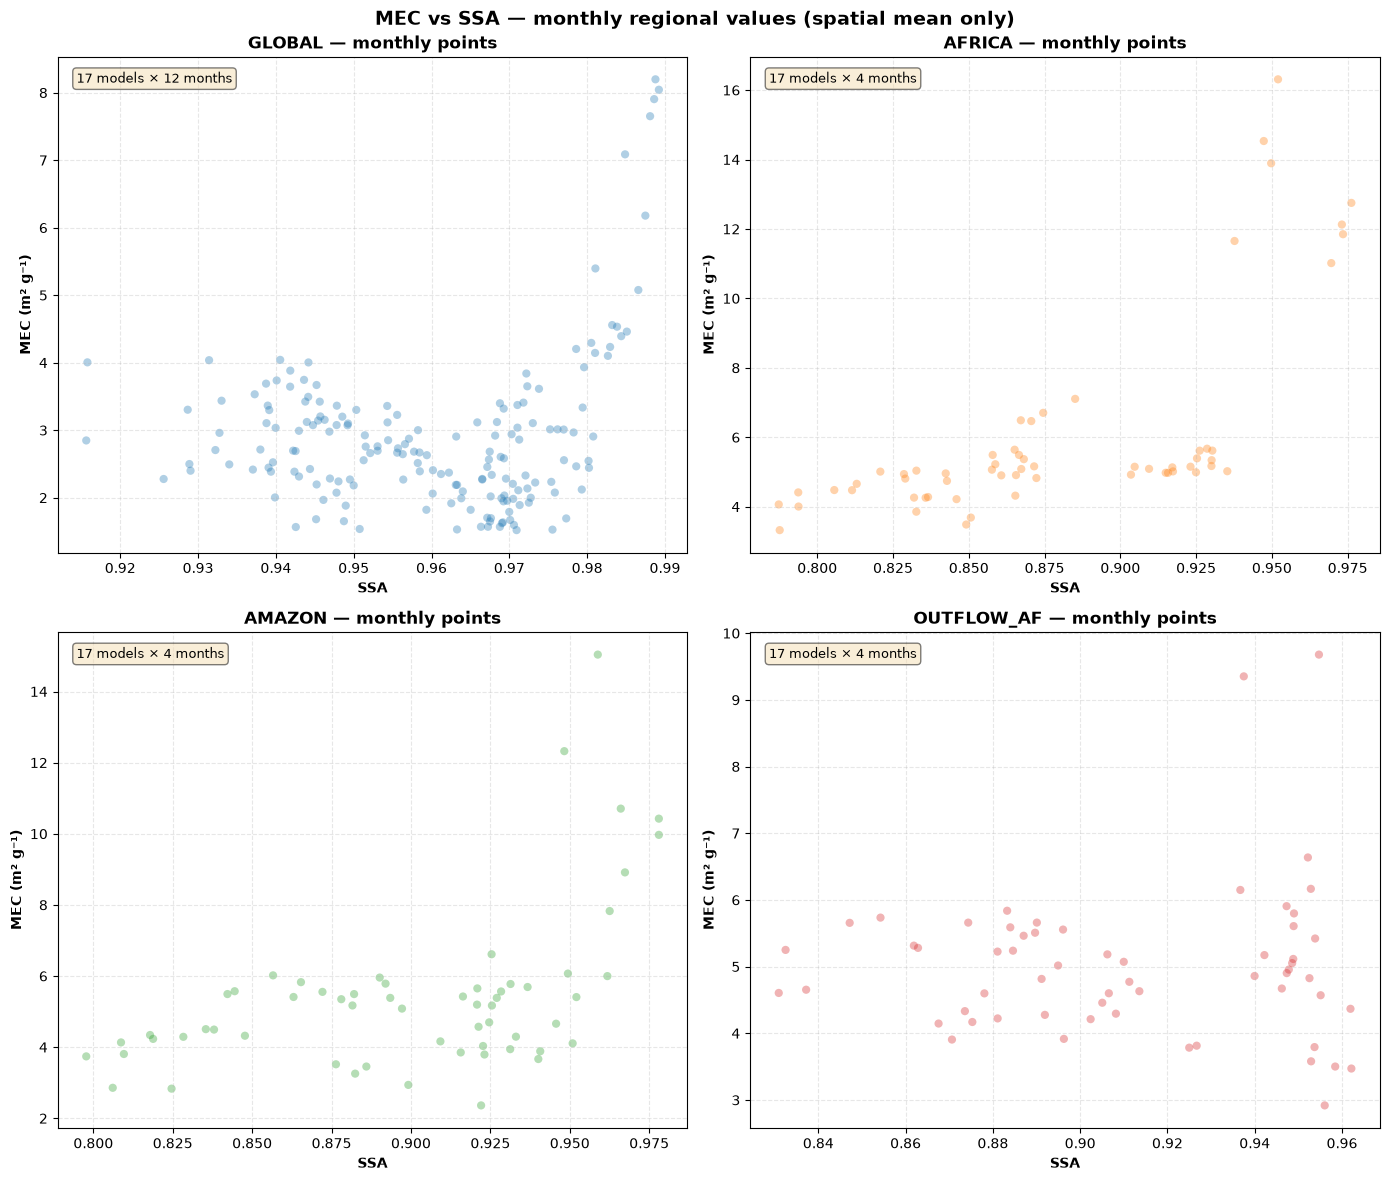

Saved: SSA_MEC_scatter_monthly.png


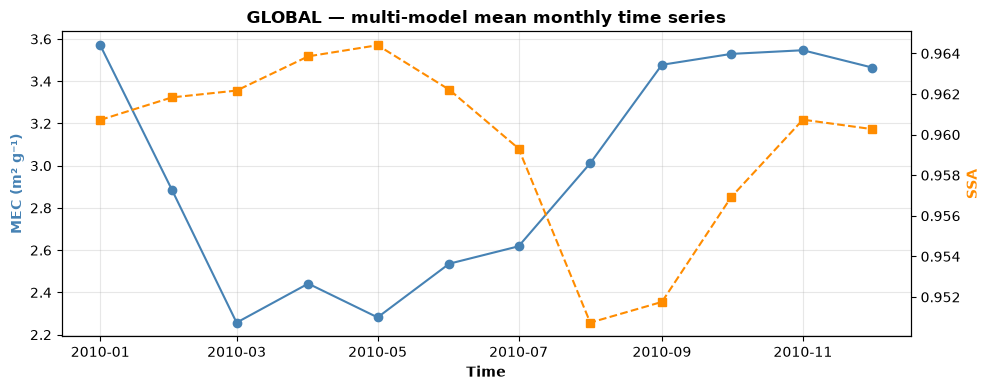

Saved: SSA_MEC_monthly_timeseries_global.png


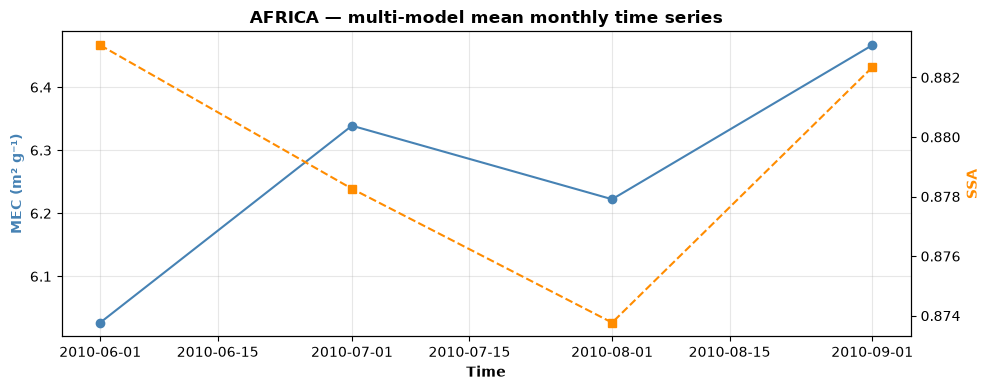

Saved: SSA_MEC_monthly_timeseries_africa.png


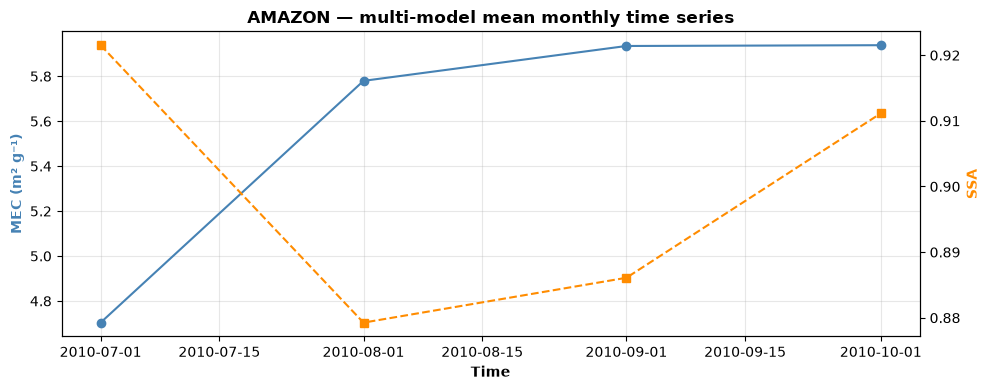

Saved: SSA_MEC_monthly_timeseries_amazon.png


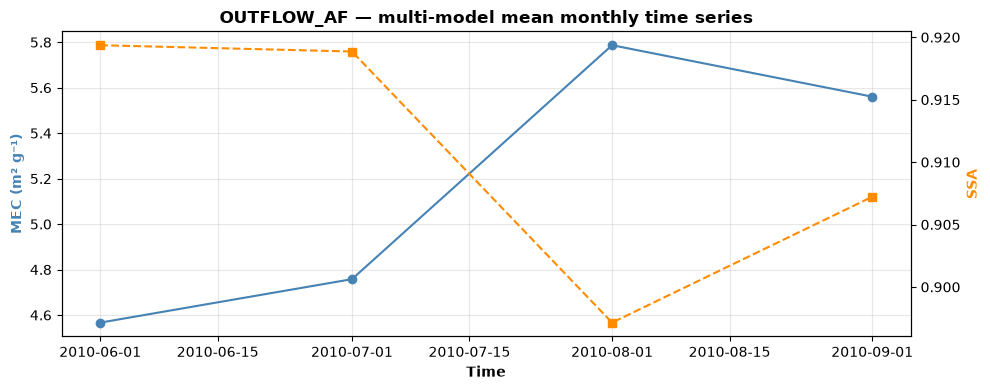

Saved: SSA_MEC_monthly_timeseries_outflow_af.png


In [12]:
# --make monthly plot with different colors for each month --

if region_monthly:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, (region, df) in enumerate(region_monthly.items()):
        if df.empty or 'SSA' not in df.columns:
            continue
        ax = axes[idx]
        ax.scatter(df['SSA'], df['MEC'], s=35, alpha=0.35, color=colors[idx], edgecolors='none')
        ax.set_xlabel('SSA', fontweight='bold')
        ax.set_ylabel('MEC (m² g⁻¹)', fontweight='bold')
        ax.set_title(f'{region.upper()} — monthly points', fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        n_models = df['model'].nunique()
        n_months = df['time'].nunique()
        ax.text(0.03, 0.97, f'{n_models} models × {n_months} months', transform=ax.transAxes,
                va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('MEC vs SSA — monthly regional values (spatial mean only)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = Path(project_root) / 'notebooks' / 'SSA_MEC_scatter_monthly.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out.name}')

    # Per-region monthly time series (regional mean MEC and SSA vs time)
    for region, df in region_monthly.items():
        if df.empty or 'SSA' not in df.columns:
            continue
        ts = df.groupby('time')[['MEC', 'SSA']].mean().sort_index()
        fig, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(ts.index, ts['MEC'], 'o-', color='steelblue', label='MEC')
        ax1.set_ylabel('MEC (m² g⁻¹)', color='steelblue', fontweight='bold')
        ax2 = ax1.twinx()
        ax2.plot(ts.index, ts['SSA'], 's--', color='darkorange', label='SSA')
        ax2.set_ylabel('SSA', color='darkorange', fontweight='bold')
        ax1.set_xlabel('Time', fontweight='bold')
        ax1.set_title(f'{region.upper()} — multi-model mean monthly time series', fontweight='bold')
        ax1.grid(True, alpha=0.3)
        plt.tight_layout()
        out_ts = Path(project_root) / 'notebooks' / f'SSA_MEC_monthly_timeseries_{region}.png'
        plt.savefig(out_ts, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out_ts.name}')
else:
    print('No monthly regional data to plot')


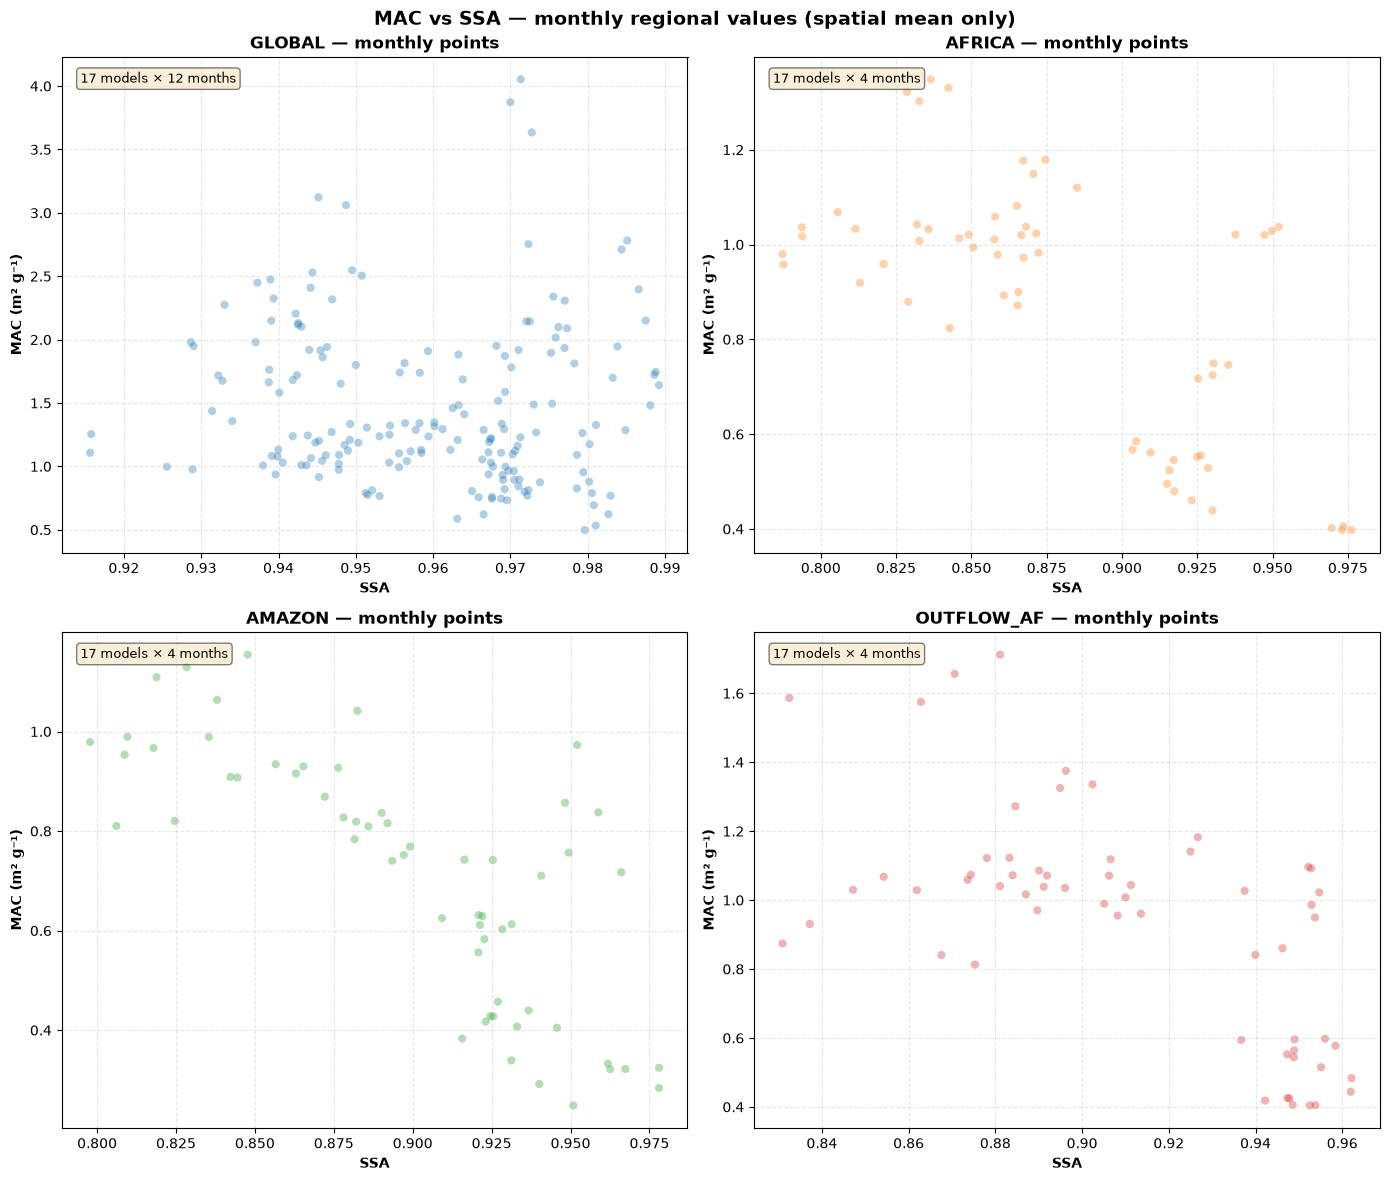

Saved: SSA_MAC_scatter_monthly.png


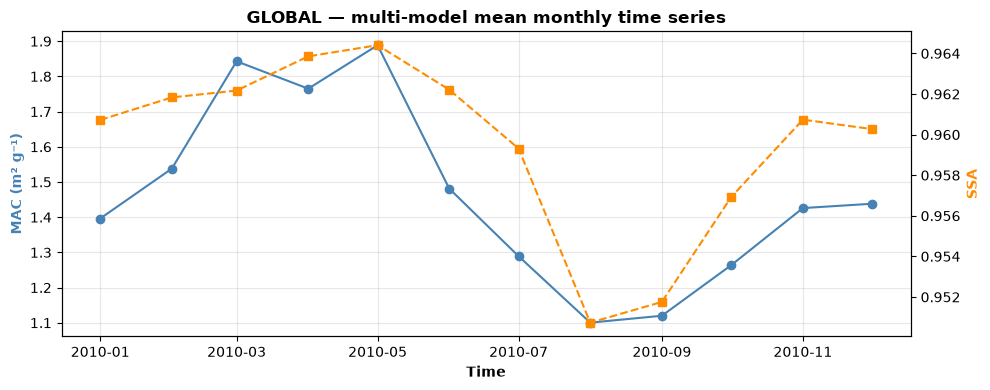

Saved: SSA_MAC_monthly_timeseries_global.png


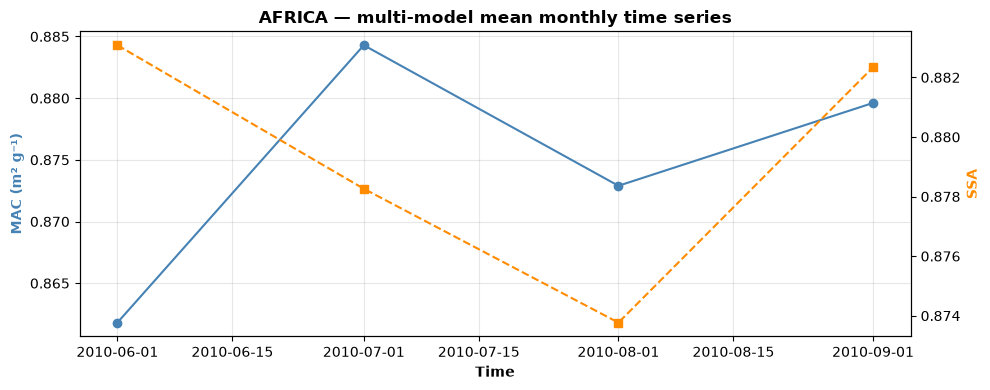

Saved: SSA_MAC_monthly_timeseries_africa.png


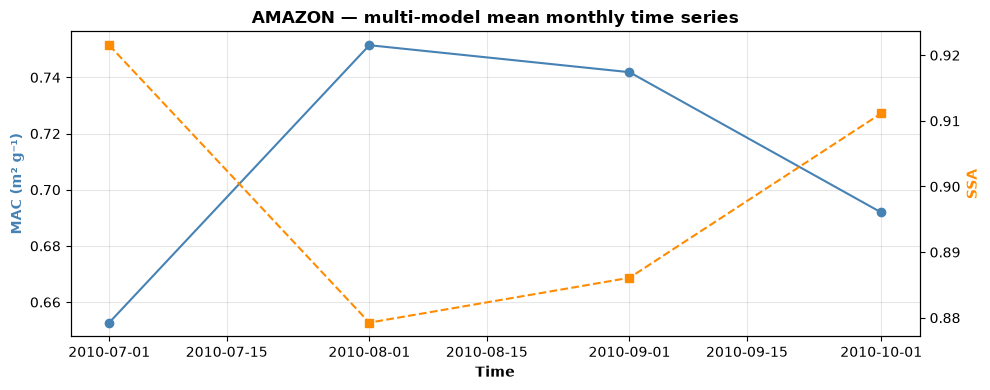

Saved: SSA_MAC_monthly_timeseries_amazon.png


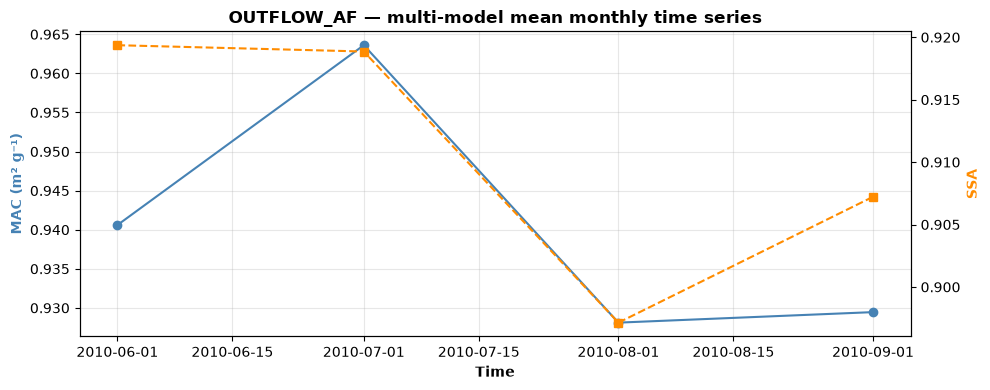

Saved: SSA_MAC_monthly_timeseries_outflow_af.png


In [ ]:
if region_monthly:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for idx, (region, df) in enumerate(region_monthly.items()):
        if df.empty or 'SSA' not in df.columns:
            continue
        ax = axes[idx]
        ax.scatter(df['SSA'], df['MEC'], s=35, alpha=0.35, color=colors[idx], edgecolors='none')
        ax.set_xlabel('SSA', fontweight='bold')
        ax.set_ylabel('MEC (m² g⁻¹)', fontweight='bold')
        ax.set_title(f'{region.upper()} — monthly points', fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        n_models = df['model'].nunique()
        n_months = df['time'].nunique()
        ax.text(0.03, 0.97, f'{n_models} models × {n_months} months', transform=ax.transAxes,
                va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('MEC vs SSA — monthly regional values (spatial mean only)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = Path(project_root) / 'notebooks' / 'SSA_MEC_scatter_monthly.png'
    plt.savefig(out, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f'Saved: {out.name}')

    # Per-region monthly time series (regional mean MEC and SSA vs time)
    for region, df in region_monthly.items():
        if df.empty or 'SSA' not in df.columns:
            continue
        ts = df.groupby('time')[['MAC', 'SSA']].mean().sort_index()
        fig, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(ts.index, ts['MAC'], 'o-', color='steelblue', label='MAC')
        ax1.set_ylabel('MAC (m² g⁻¹)', color='steelblue', fontweight='bold')
        ax2 = ax1.twinx()
        ax2.plot(ts.index, ts['SSA'], 's--', color='darkorange', label='SSA')
        ax2.set_ylabel('SSA', color='darkorange', fontweight='bold')
        ax1.set_xlabel('Time', fontweight='bold')
        ax1.set_title(f'{region.upper()} — multi-model mean monthly time series', fontweight='bold')
        ax1.grid(True, alpha=0.3)
        plt.tight_layout()
        out_ts = Path(project_root) / 'notebooks' / f'SSA_MAC_monthly_timeseries_{region}.png'
        plt.savefig(out_ts, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved: {out_ts.name}')
else:
    print('No monthly regional data to plot')


## 7. Regional-mean scatter plots (one point per model)


### THEORY 
$$
\begin{align*}
MAC &= \frac{AAOD}{Col\_Density} \\
L^2 M^{-1} &= [-] (M L^{-2})^{-1} \\
AAOD &= AOD (1-SSA) \ [unitless]\\
MAC  &= \frac{AOD (1-SSA)}{Col\_Density} \\
MEC  &= \frac{AOD}{Col\_Density} \\
MAC  &=  MEC (1-SSA)
\end{align*}
$$

MEC is effectiveness in extinction per unit mass of aerosol, which assumed to be primarily determined by aersol mixture, and aerosol size (amount of mie scattering). For absorption, the main compoenent should come from BC/EC and OM ratio and secondarily Dust, the secondary effect should come from hygroscopicity. Therefore the relation between MAC and SSA should mainly depending on aerosol composition and mixing state. Since model often assum similar BC/OM ratio for emission, the MAC for specific type of aerosol mixture like fire, seasalt and dust should have a good statics correlation. Based on this relation, a regression should fit without intercept and with 1-ssa. 

what did i miss? A bad correspondance to MEC value with the slope means SSA is not sensitive in the data. Explaination? Might be the best to not look globally anyway. Why not filtering land and sea quickly? check the SPEXone data? on SSA? and land sea mask + 250km away from the land and in pacific? that could be a good one. 


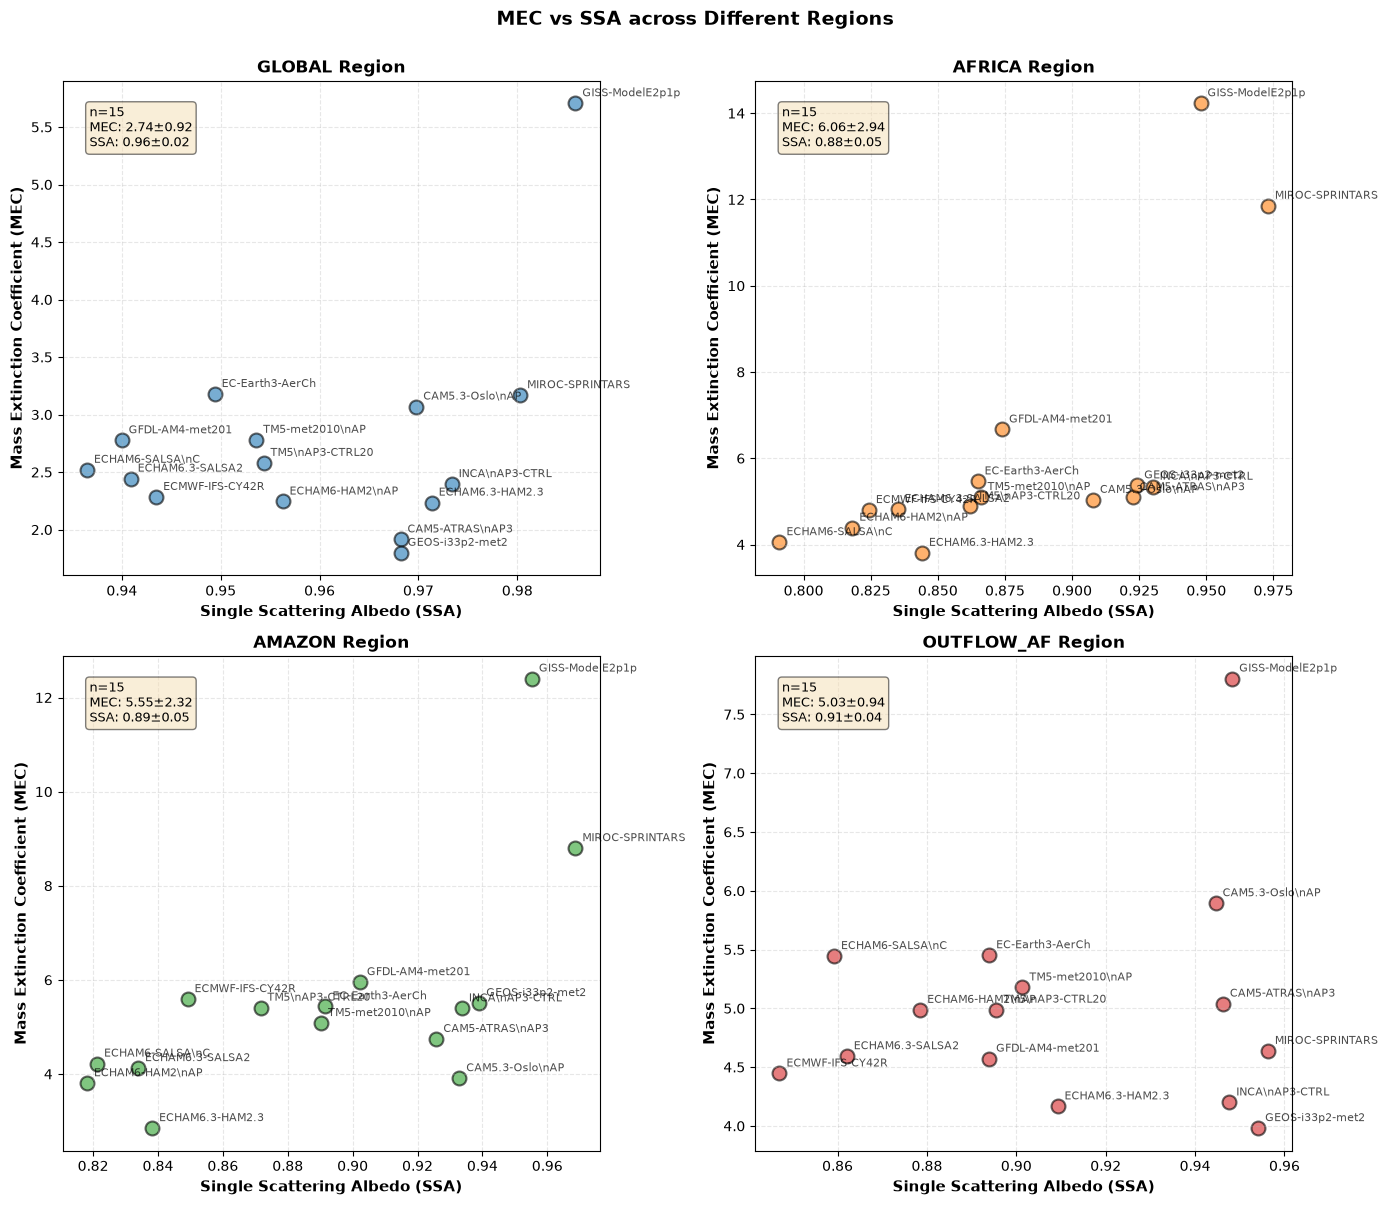

✓ Scatter plot saved as 'SSA_MEC_scatter_plot.png'


In [ ]:
if region_data:
    # Create figure with subplots (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for idx, (region, df) in enumerate(region_data.items()):
        ax = axes[idx]
        
        # Create scatter plot
        scatter = ax.scatter(df['SSA'], df['MEC'], 
                            s=100, alpha=0.6, color=colors[idx],
                            edgecolors='black', linewidth=1.5)
        
        # Add labels for each point (model name)
        for i, model in enumerate(df['model']):
            ax.annotate(model.replace('_', '\\n')[:15], 
                        (df['SSA'].iloc[i], df['MEC'].iloc[i]),
                        fontsize=8, alpha=0.7, 
                        xytext=(5, 5), textcoords='offset points')
        
        # Labels and title
        ax.set_xlabel('Single Scattering Albedo (SSA)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Mass Extinction Coefficient (MEC)', fontsize=11, fontweight='bold')
        ax.set_title(f'{region.upper()} Region', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add statistics box
        stats_text = f"n={len(df)}\nMEC: {df['MEC'].mean():.2f}±{df['MEC'].std():.2f}\nSSA: {df['SSA'].mean():.2f}±{df['SSA'].std():.2f}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('MEC vs SSA across Different Regions', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(Path(project_root) / 'notebooks' / 'SSA_MEC_scatter_plot.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Scatter plot saved as 'SSA_MEC_scatter_plot.png'")
else:
    print("✗ No region data available for plotting")

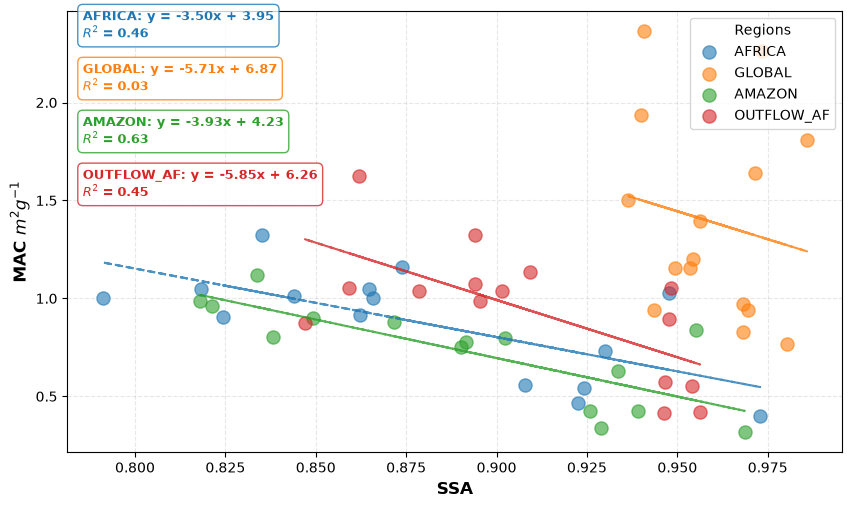

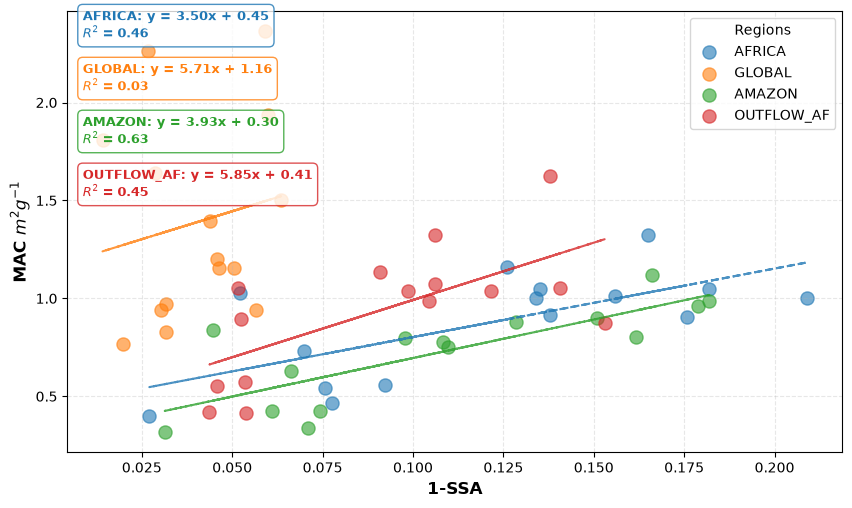

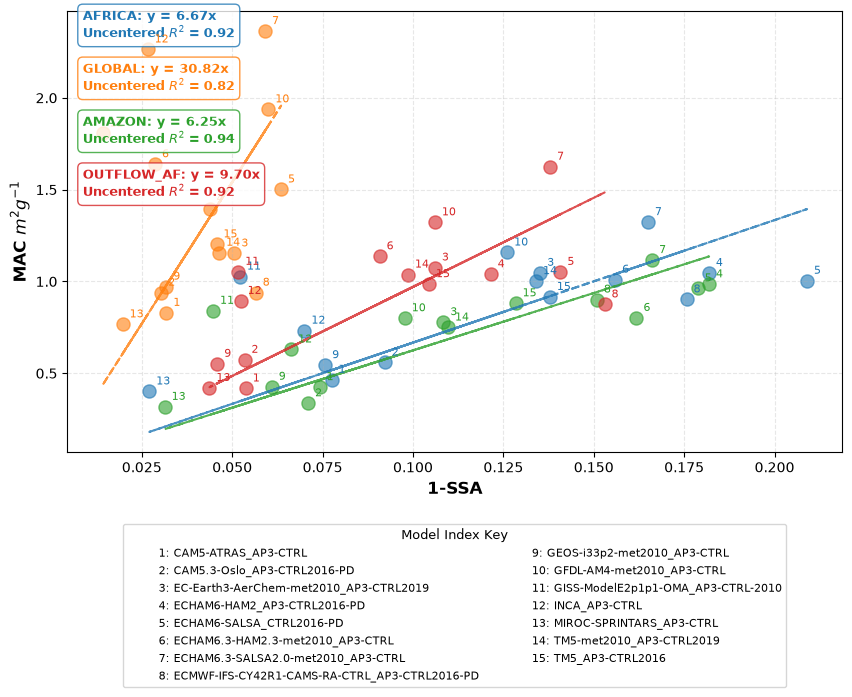

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

def plot_combined_regions(region_data, x_col, y_col, x_label, y_label, 
                          save_fig=False, filename="plot.png", 
                          use_model_numbers=False, force_intercept_zero=False):
    """
    Plots regions with regression stats inside and a wrapped model legend below the x-axis.
    Includes option to force the linear regression intercept through the origin (0,0).
    """
    fig, ax = plt.subplots(figsize=(10, 7)) 
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    model_col = 'model' if 'model' in next(iter(region_data.values())).columns else 'model_name'
    all_models = sorted(list(set().union(*[df[model_col].values for df in region_data.values()])))

    for idx, (region, df) in enumerate(region_data.items()):
        color = colors[idx % len(colors)]
        x_data = df[x_col].values
        y_data = df[y_col].values
        
        # Plot Scatter
        ax.scatter(x_data, y_data, s=90, alpha=0.6, color=color, label=f"{region.upper()}")
        
        if use_model_numbers:
            for _, row in df.iterrows():
                model_idx = all_models.index(row[model_col]) + 1
                ax.annotate(str(model_idx), (row[x_col], row[y_col]), 
                            xytext=(5, 5), textcoords="offset points", fontsize=8, color=color)
        
        # --- Regression Engine ---
        if force_intercept_zero:
            # Force intercept to 0: y = mx
            # m = sum(x*y) / sum(x^2)
            slope = np.sum(x_data * y_data) / np.sum(x_data**2)
            line = slope * x_data
            
            # Uncentered R^2 calculation
            residuals = y_data - line
            r_squared = 1 - (np.sum(residuals**2) / np.sum(y_data**2))
            
            # Equation formatting
            eq_str = f"y = {slope:.2f}x"
            r2_label = f"Uncentered $R^2$"
        else:
            # Standard Ordinary Least Squares (OLS)
            slope, intercept, r_value, _, _ = linregress(x_data, y_data)
            line = slope * x_data + intercept
            r_squared = r_value**2
            
            # Equation formatting
            sign = "+" if intercept >= 0 else "-"
            eq_str = f"y = {slope:.2f}x {sign} {abs(intercept):.2f}"
            r2_label = f"$R^2$"
            
        ax.plot(x_data, line, color=color, linestyle='--', alpha=0.8)
        
        # Combined stats label box
        text_label = f"{region.upper()}: {eq_str}\n{r2_label} = {r_squared:.2f}"
        ax.text(0.02, 0.94 - (idx * 0.12), text_label, transform=ax.transAxes, 
                color=color, fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor=color))

    ax.set_xlabel(x_label, fontsize=12, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(title="Regions", loc="upper right")
    
    if use_model_numbers:
        legend_elements = [plt.Line2D([0], [0], marker='', color='w', label=f"{i+1}: {model}") 
                           for i, model in enumerate(all_models)]
        ax.legend(handles=legend_elements, title="Model Index Key", 
                  loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                  fontsize=8, title_fontsize=9, ncol=2)

    # Reserves room at the bottom for the model index wrapper
    plt.subplots_adjust(bottom=0.25)
    
    if save_fig:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Saved: {filename}")
        
    plt.show()
# Setup data column
for reg in region_data:
    region_data[reg]['1-SSA'] = 1 - region_data[reg]['SSA']

# Plot 1: Standard with saving enabled
plot_combined_regions(
    region_data, 
    x_col='SSA', 
    y_col='MAC', 
    x_label='SSA', 
    y_label='MAC $m^2 g^{-1}$',
    save_fig=False, 
    use_model_numbers=False
)
plot_combined_regions(
    region_data, 
    x_col='1-SSA', 
    y_col='MAC', 
    x_label='1-SSA', 
    y_label='MAC $m^2 g^{-1}$',
    save_fig=False,
    filename="MAC_vs_1-SSA_regions.png",
    use_model_numbers=False
)
plot_combined_regions(
    region_data, 
    x_col='1-SSA', 
    y_col='MAC', 
    x_label='1-SSA', 
    y_label='MAC $m^2 g^{-1}$',
    save_fig=False,
    filename="MAC_vs_1-SSA_regions.png",
    force_intercept_zero= True,
    use_model_numbers=True
)
# plot_combined_regions(
#     region_data, 
#     x_col='SSA', 
#     y_col='MEC', 
#     x_label='SSA', 
#     y_label='MEC $m^2 g^{-1}$',
#     save_fig=False,
#     use_model_numbers=True
# )

## 9. Individual high-quality plots per region


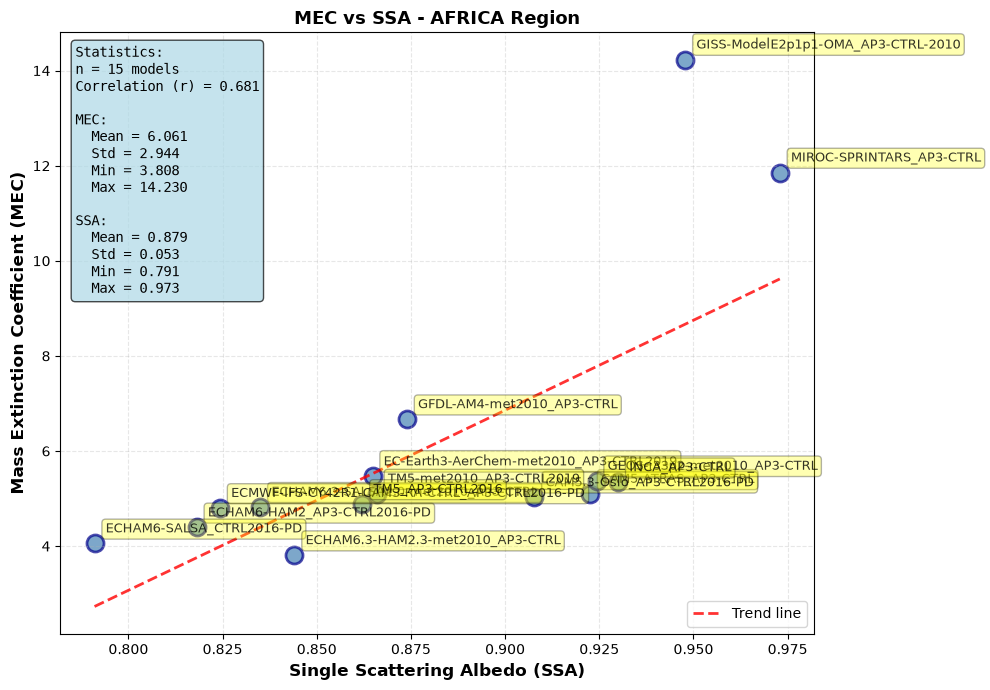

✓ Plot saved for africa: SSA_MEC_scatter_africa.png


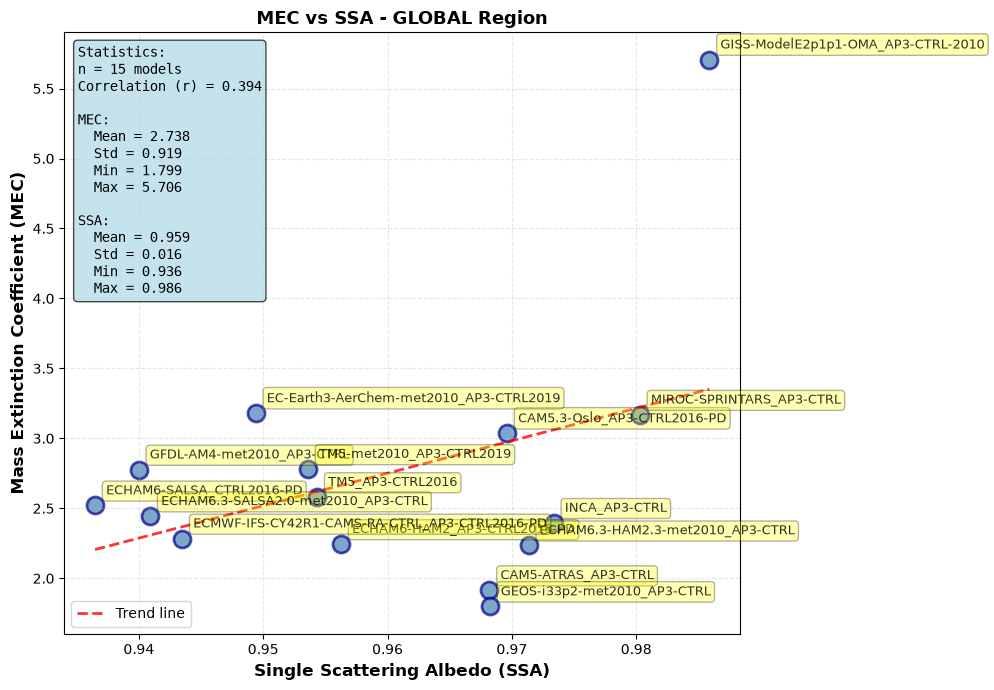

✓ Plot saved for global: SSA_MEC_scatter_global.png


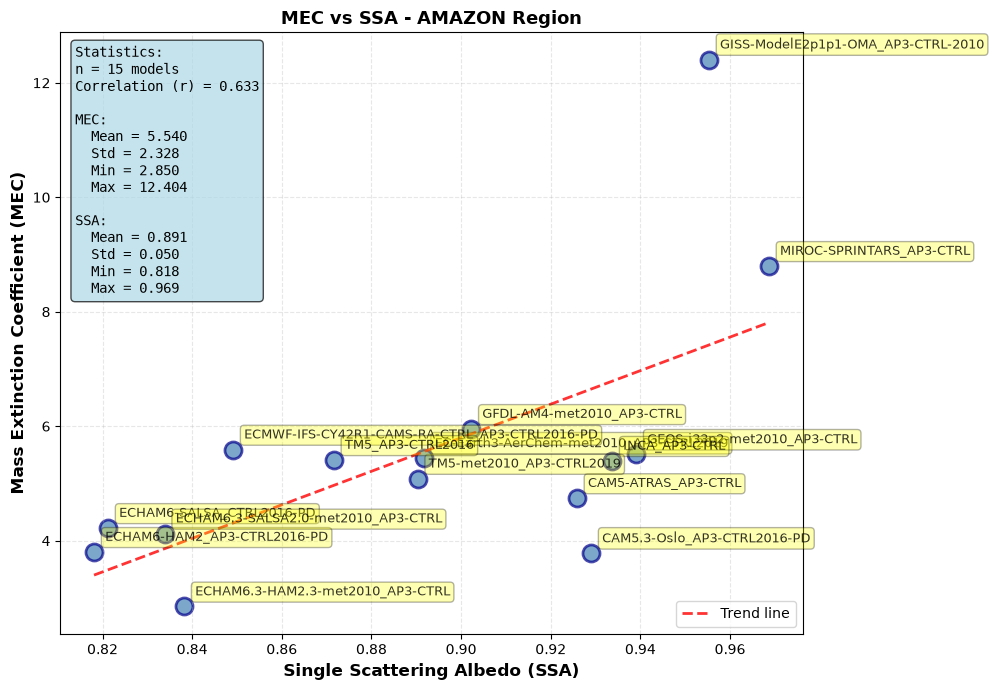

✓ Plot saved for amazon: SSA_MEC_scatter_amazon.png


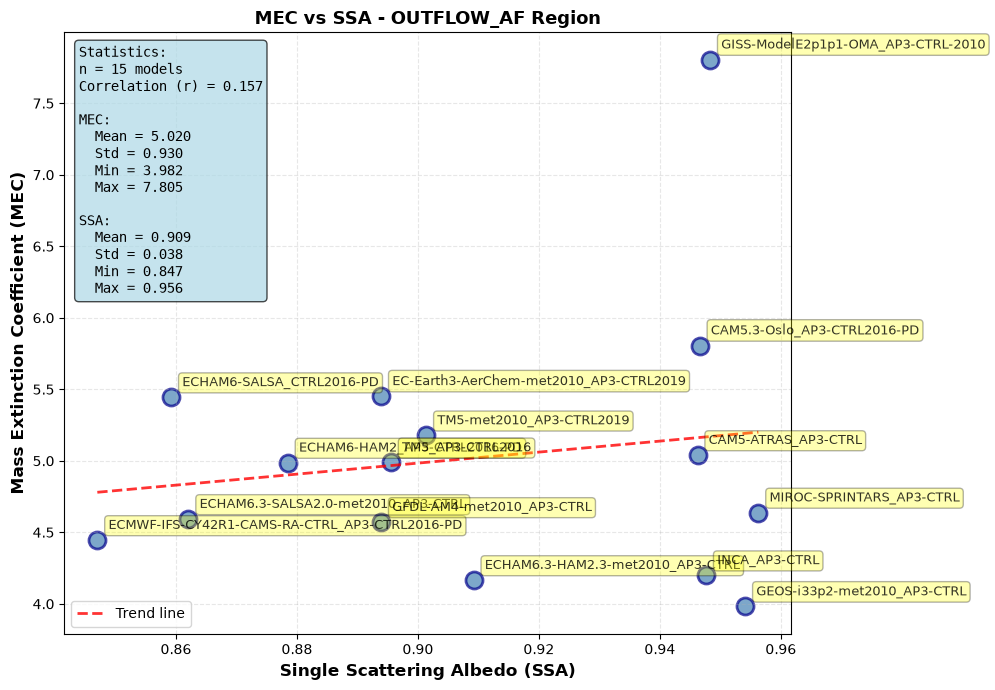

✓ Plot saved for outflow_af: SSA_MEC_scatter_outflow_af.png


In [ ]:
if region_data:
    for region, df in region_data.items():
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Create scatter plot
        scatter = ax.scatter(df['SSA'], df['MEC'], 
                            s=150, alpha=0.7, color='steelblue',
                            edgecolors='darkblue', linewidth=2)
        
        # Add trend line
        z = np.polyfit(df['SSA'], df['MEC'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(df['SSA'].min(), df['SSA'].max(), 100)
        ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label='Trend line')
        
        # Add labels for each point
        for i, model in enumerate(df['model']):
            ax.annotate(model, 
                        (df['SSA'].iloc[i], df['MEC'].iloc[i]),
                        fontsize=9, alpha=0.8, 
                        xytext=(8, 8), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
        
        # Calculate correlation
        correlation = df['SSA'].corr(df['MEC'])
        
        # Labels and title
        ax.set_xlabel('Single Scattering Albedo (SSA)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Mass Extinction Coefficient (MEC)', fontsize=12, fontweight='bold')
        ax.set_title(f'MEC vs SSA - {region.upper()} Region', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=10)
        
        # Add statistics box
        stats_text = (
            f"Statistics:\n"
            f"n = {len(df)} models\n"
            f"Correlation (r) = {correlation:.3f}\n"
            f"\nMEC:\n"
            f"  Mean = {df['MEC'].mean():.3f}\n"
            f"  Std = {df['MEC'].std():.3f}\n"
            f"  Min = {df['MEC'].min():.3f}\n"
            f"  Max = {df['MEC'].max():.3f}\n"
            f"\nSSA:\n"
            f"  Mean = {df['SSA'].mean():.3f}\n"
            f"  Std = {df['SSA'].std():.3f}\n"
            f"  Min = {df['SSA'].min():.3f}\n"
            f"  Max = {df['SSA'].max():.3f}"
        )
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
        
        plt.tight_layout()
        plot_filename = Path(project_root) / 'notebooks' / f'SSA_MEC_scatter_{region}.png'
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Plot saved for {region}: {plot_filename.name}")

## 10. Summary statistics table


In [ ]:
if region_data:
    print("\n" + "="*80)
    print("SUMMARY STATISTICS ACROSS REGIONS")
    print("="*80 + "\n")
    
    summary_stats = []
    
    for region, df in region_data.items():
        correlation = df['SSA'].corr(df['MEC'])
        summary_stats.append({
            'Region': region.upper(),
            'N_Models': len(df),
            'MEC_Mean': f"{df['MEC'].mean():.4f}",
            'MEC_Std': f"{df['MEC'].std():.4f}",
            'SSA_Mean': f"{df['SSA'].mean():.4f}",
            'SSA_Std': f"{df['SSA'].std():.4f}",
            'Correlation': f"{correlation:.4f}"
        })
    
    summary_df = pd.DataFrame(summary_stats)
    print(summary_df.to_string(index=False))
    
    # Save summary to CSV
    csv_path = Path(project_root) / 'notebooks' / 'SSA_MEC_summary_statistics.csv'
    summary_df.to_csv(csv_path, index=False)
    print(f"\n✓ Summary statistics saved to: {csv_path.name}")


SUMMARY STATISTICS ACROSS REGIONS

    Region  N_Models MEC_Mean MEC_Std SSA_Mean SSA_Std Correlation
    AFRICA        15   6.0614  2.9438   0.8790  0.0529      0.6807
    GLOBAL        15   2.7378  0.9189   0.9594  0.0156      0.3935
    AMAZON        15   5.5405  2.3284   0.8912  0.0503      0.6333
OUTFLOW_AF        15   5.0199  0.9298   0.9093  0.0380      0.1574

✓ Summary statistics saved to: SSA_MEC_summary_statistics.csv


## 11. Export detailed model data


In [ ]:
if region_data:
    print("\nDetailed Model Data by Region:")
    print("="*80 + "\n")
    
    for region, df in region_data.items():
        print(f"\n{region.upper()} REGION:")
        print("-" * 80)
        
        # Sort by MEC value
        df_sorted = df.sort_values('MEC', ascending=False)
        
        # Display table
        display_df = df_sorted.copy()
        display_df['SSA'] = display_df['SSA'].round(4)
        display_df['MEC'] = display_df['MEC'].round(4)
        print(display_df.to_string(index=False))
        
        # Save to CSV
        csv_path = Path(project_root) / 'notebooks' / f'SSA_MEC_data_{region}.csv'
        df_sorted.to_csv(csv_path, index=False)
        print(f"✓ Data saved to: {csv_path.name}")

## 12. Cross-regional comparison


In [ ]:
if region_data and len(region_data) > 1:
    # Create a comparison plot across regions
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    regions_list = list(region_data.keys())
    
    # MEC comparison
    ax1 = axes[0]
    for i, region in enumerate(regions_list):
        df = region_data[region]
        ax1.boxplot([df['MEC']], positions=[i], widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor=plt.cm.Set3(i), alpha=0.7))
    ax1.set_xticklabels([r.upper() for r in regions_list])
    ax1.set_ylabel('Mass Extinction Coefficient (MEC)', fontsize=11, fontweight='bold')
    ax1.set_title('MEC Distribution Across Regions', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # SSA comparison
    ax2 = axes[1]
    for i, region in enumerate(regions_list):
        df = region_data[region]
        ax2.boxplot([df['SSA']], positions=[i], widths=0.6, patch_artist=True,
                    boxprops=dict(facecolor=plt.cm.Set3(i), alpha=0.7))
    ax2.set_xticklabels([r.upper() for r in regions_list])
    ax2.set_ylabel('Single Scattering Albedo (SSA)', fontsize=11, fontweight='bold')
    ax2.set_title('SSA Distribution Across Regions', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Cross-Regional Comparison of MEC and SSA', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plot_filename = Path(project_root) / 'notebooks' / 'SSA_MEC_cross_regional_comparison.png'
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Cross-regional comparison plot saved: {plot_filename.name}")

## 13. Summary and notes


In [ ]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nProject Root: {project_root}")
print(f"Data Directory: {pickle_dir}")
print(f"\nRegions Analyzed: {', '.join([r.upper() for r in region_data.keys()])}")
print(f"Total Models: {sum(len(df) for df in region_data.values())}")
print("\nOutput Files Generated:")
output_dir = Path(project_root) / 'notebooks'
for output_file in sorted(output_dir.glob('SSA_MEC*.png')) + sorted(output_dir.glob('SSA_MEC*.csv')):
    print(f"  ✓ {output_file.name}")
print("\nNote: All plots and data files are saved in the notebooks directory.")
print("="*80)